##### ***深度循环神经网络***
###### 对于之前的RNN，我们仅仅使用了一个单向循环隐藏层，其中，隐变量和观测值与具体的函数形式的交互方式是相当随意的。所以我们需要添加更多的层来解决模型不够复杂的问题。然而对于循环神经网络我们首先要确定如何添加更多的层，以及在哪里添加额外的非线性，除此之外我们还要考虑如何保证梯度稳定。<br>事实上，我们可以将多层循环神经网络堆叠在一起，通过对几个简单层的组合，产生了一个灵活的机制，如下图展示了一个具有L个隐藏层的深度循环神经网络，每个隐状态都连续地传递到当前层的下一个时间步和下一层的当前时间步。
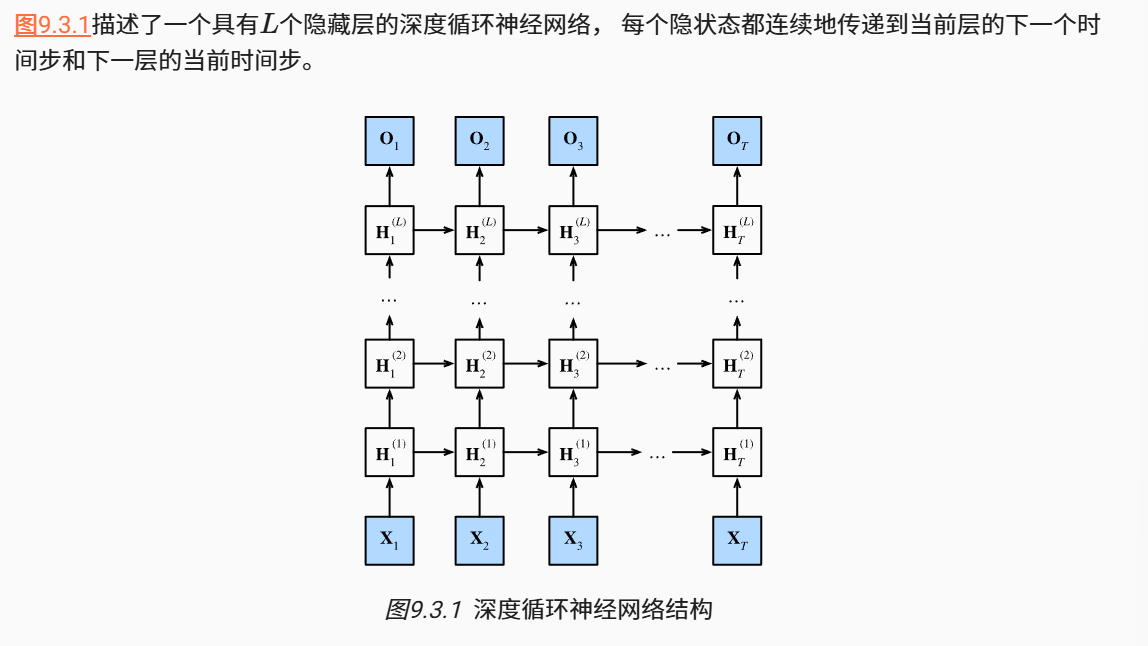
##### ***函数依赖关系***
###### 为更直观理解，我们将深度架构中的函数依赖关系形式化。假设在时间步t有一个小批量的输入数据$X_t\in\mathbb{R}^{n\times d}$，其中n是样本数，d是每个样本的输入数。同时将$l^{th}$隐藏层($l = 1,2,...,L$)的隐状态设为$H_t^{(l)}\in \mathbb{R}^{n\times h}$(h是隐藏单元数)，输出层变量设为$O_t\in \mathbb{R}^{n\times q}$(q为输出数)。设置$H_t^0 = X_t$，第$l$个隐藏层的隐状态激活函数用$\sigma_l$表示，则：
$$H_t^{(l)} = \sigma(H_t^{(l-1)}W_{xh}^{(l)} + H_{t-1}^{(l)}W_{hh}^{(l)} + b_h^{(l)})$$
###### 其中，$W_{xh}^{(l)}\in \mathbb{R}^{h\times h}$，$W_{hh}^{(l)}\in \mathbb{R}^{h\times h}$，$b_h^{(l)}\in \mathbb{R}^{1\times h}$，是第$l$个隐藏层的模型参数。<br>最后，输出层的计算仅基于第$l$个隐藏层最终的隐状态：
$$O_t = H_t^{(L)}W_{hq} + b_q$$
###### 与MLP一样，隐藏层的数量$L$和隐藏单元的数量$h$都是超参数，与此同时可以将隐状态替换为GRU或LSTM来提高模型的表达能力。

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

In [2]:
vocab_size, num_hiddens, num_layers = len(vocab), 256, 2
num_inputs = vocab_size
device = d2l.try_gpu()
lstm_layer = nn.LSTM(num_inputs, num_hiddens, num_layers)
model = d2l.RNNModel(lstm_layer, vocab_size)
model = model.to(device)

perplexity 1.0, 35753.7 tokens/sec on cpu
time traveller for so it will be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


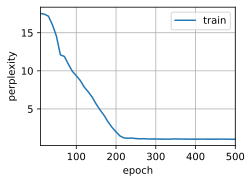

In [3]:
num_epochs, lr = 500, 2
d2l.train_ch8(model, train_iter, vocab, lr*1.0, num_epochs, device)